
# PLSR Trait Distributions by Season and PFT (SHIFT – Dangermond)

This notebook reproduces CHL, LMA, and LWC distribution plots (Early / Mid / Late) using the PLSR trait stack.  
It supports optional stratification by Plant Functional Type (PFT) if you provide a PFT mask on the same grid.

**How to use**
1. Update the configuration cell (paths, optional PFT mask, class mapping).
2. Run all cells.
3. Figures will be saved to `./figures/`.


In [2]:

# --- CONFIG ---
NC_PATH = "/home/renatob/data/FluoData1/aviris_dangermond/shift_dangermond_data_v1/PLSR/PLSR_dangermond_traits.nc"

# Optional PFT mask (NetCDF or GeoTIFF on same grid). If not available, set to None.
PFT_MASK_PATH = None  # e.g., "/path/to/pft_mask.nc" or "/path/to/pft_mask.tif"
PFT_VAR = "PFT"       # variable name inside NetCDF (ignored for GeoTIFF)
PFT_CLASSES = {1: "PFT 1", 2: "PFT 2", 3: "PFT 3"}  # change labels as needed

# Variables in the PLSR file
VAR_CHL = "CHL_CCM"   # chlorophyll (units vary by product; see notes below)
VAR_LMA = "LMA"       # g m^-2
VAR_LWC = "LWC"       # usually leaf EWT, g m^-2 (one-sided leaf area)

# Output directory for figures
OUTDIR = "./figures"

# --- UNIT CONVERSIONS ---
# Final axes will match the units in the tuple: (target_unit_label, conversion_fn)
# Default assumptions for the PLSR file:
# - CHL_CCM: if your source is µg cm^-2 already, set lambda x: x; if it's g m^-2, use x/10.
CHL_CONV = ("µg cm$^{-2}$", lambda x: x)  # adjust if needed
LMA_CONV = ("g m$^{-2}$",   lambda x: x)
# PLSR LWC is typically g m^-2; convert to g cm^-2 for comparability with your manuscript
LWC_CONV = ("g cm$^{-2}$",  lambda x: x/10000.0)

# Histogram & plotting
NBINS = 60
ALPHA = 0.55
COLORS = {1: "tab:blue", 2: "tab:green", 3: "tab:red"}
SEED = 42


In [3]:

import os, warnings, math
import numpy as np
import xarray as xr
import rioxarray as rxr

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter

np.random.seed(SEED)
os.makedirs(OUTDIR, exist_ok=True)

def load_plsr_dataset(path):
    ds = xr.open_dataset(path, mask_and_scale=False, decode_times=True)
    # Ensure lat/lon names are standard
    return ds

def load_pft_mask(mask_path, var_name="PFT", template_ds=None):
    if mask_path is None:
        return None
    ext = os.path.splitext(mask_path)[1].lower()
    if ext in [".nc", ".nc4", ".cdf", ".netcdf"]:
        m = xr.open_dataset(mask_path)
        if var_name in m:
            p = m[var_name]
        else:
            # try to pick the first data var
            p = next(iter(m.data_vars.values()))
        # attempt to align to template
        if template_ds is not None:
            try:
                p = p.rename({list(p.dims)[-2]: "lat", list(p.dims)[-1]: "lon"}) if "lat" not in p.dims else p
                p = p.interp_like(template_ds[VAR_LMA], method="nearest")
            except Exception:
                pass
        return p.astype("int32")
    else:
        # Assume raster (GeoTIFF)
        p = rxr.open_rasterio(mask_path).squeeze()
        if template_ds is not None:
            try:
                p = p.rio.reproject_match(template_ds[VAR_LMA])
            except Exception:
                pass
        return p.astype("int32")

def season_labels_from_time(time_index):
    # Split into Early/Mid/Late by tertiles of acquisition dates
    tvals = xr.decode_cf(xr.Dataset({"t": time_index})).t.values if "t" in time_index.dims else np.array(time_index.values)
    order = np.argsort(tvals)
    n = len(tvals)
    edges = [0, n//3, 2*n//3, n]
    groups = {}
    names = ["Early", "Mid", "Late"]
    for i,(a,b) in enumerate(zip(edges[:-1], edges[1:])):
        idx = order[a:b]
        groups[names[i]] = np.sort(idx)
    return groups  # dict: name -> indices

def clean_and_flatten(arr):
    a = np.asarray(arr).ravel()
    return a[np.isfinite(a)]

def apply_conv(data, conv):
    label, fn = conv
    return fn(data), label

def stats_string(arr):
    if arr.size == 0:
        return "—"
    mu = np.nanmean(arr)
    sd = np.nanstd(arr)
    return f"{mu:.3g} ± {sd:.2g}"


In [4]:

ds = load_plsr_dataset(NC_PATH)
print(ds)

# Define seasons by tertiles of time axis
groups = season_labels_from_time(ds.time)
groups


<xarray.Dataset> Size: 3GB
Dimensions:                    (lon: 2959, lat: 2724, time: 11)
Coordinates:
  * lon                        (lon) float64 24kB -120.5 -120.5 ... -120.4
  * lat                        (lat) float64 22kB 34.57 34.57 ... 34.44 34.44
  * time                       (time) datetime64[ns] 88B 2022-02-24 ... 2022-...
Data variables:
    transverse_mercator        int64 8B ...
    CHL_CCM                    (time, lat, lon) float32 355MB ...
    LMA                        (time, lat, lon) float32 355MB ...
    LWC                        (time, lat, lon) float32 355MB ...
    Nitrogen_perc              (time, lat, lon) float32 355MB ...
    Uncertainty_CHL_CCM        (time, lat, lon) float32 355MB ...
    Uncertainty_LMA            (time, lat, lon) float32 355MB ...
    Uncertainty_LWC            (time, lat, lon) float32 355MB ...
    Uncertainty_Nitrogen_perc  (time, lat, lon) float32 355MB ...
    NDVI                       (time, lat, lon) float32 355MB ...
Attribut

{'Early': array([0, 1, 2]),
 'Mid': array([3, 4, 5, 6]),
 'Late': array([ 7,  8,  9, 10])}

In [5]:

pft = load_pft_mask(PFT_MASK_PATH, var_name=PFT_VAR, template_ds=ds)
if pft is None:
    print("No PFT mask provided — proceeding without PFT stratification (single class 'All').")
else:
    # Ensure lat/lon dims align
    # Try rename dims to match ds variables as needed
    try:
        if set(pft.dims) != set(ds[VAR_LMA].isel(time=0).dims):
            # Attempt a basic rename
            ren = {}
            for d in pft.dims:
                if d not in ds[VAR_LMA].dims:
                    # skip
                    pass
            # If mismatch persists, we'll rely on broadcasting where possible
        print("PFT mask loaded. Unique classes:", [int(v) for v in np.unique(pft.values[~np.isnan(pft.values)])])
    except Exception as e:
        print("PFT mask loaded (alignment not verified):", e)


No PFT mask provided — proceeding without PFT stratification (single class 'All').


In [6]:

# Extract arrays
CHL = ds[VAR_CHL]  # [time, lat, lon]
LMA = ds[VAR_LMA]
LWC = ds[VAR_LWC]

# Convert units
CHL_vals, CHL_unit = apply_conv(CHL, CHL_CONV)
LMA_vals, LMA_unit = apply_conv(LMA, LMA_CONV)
LWC_vals, LWC_unit = apply_conv(LWC, LWC_CONV)

CHL_vals.name, LMA_vals.name, LWC_vals.name


('CHL_CCM', 'LMA', 'LWC')

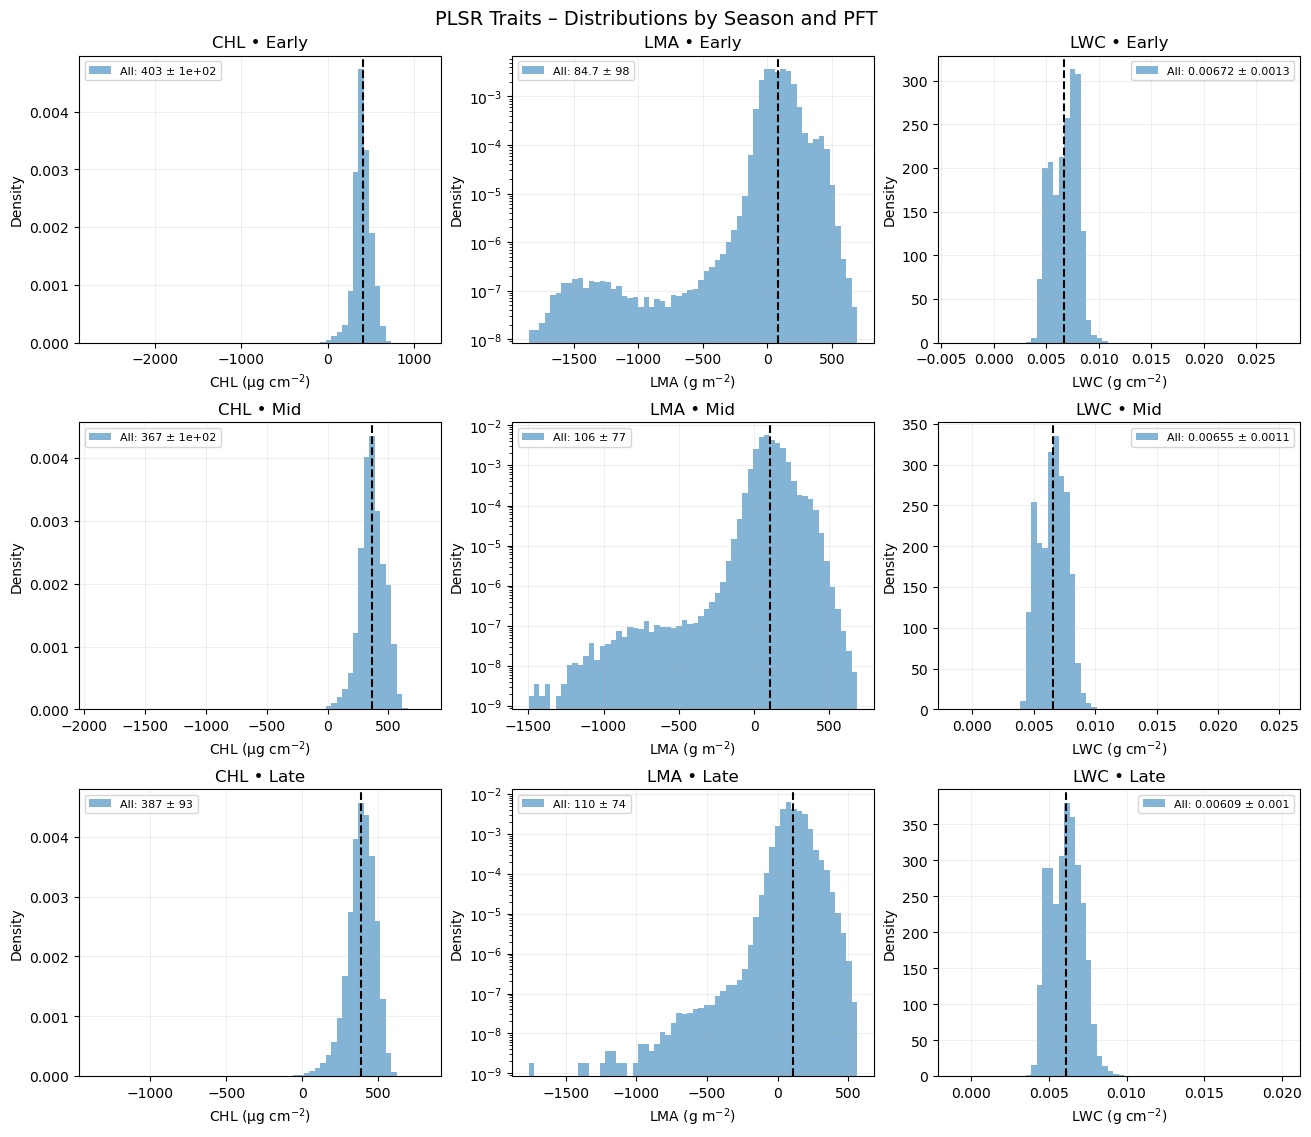

Saved: ./figures/plsr_trait_distributions_by_season.png


In [7]:

def plot_distributions_by_season_and_pft(CHL_vals, LMA_vals, LWC_vals, pft=None, outdir=OUTDIR):
    fig, axes = plt.subplots(3, 3, figsize=(13, 11), constrained_layout=True)
    panels = [("CHL", CHL_vals, CHL_unit, axes[0,0], axes[1,0], axes[2,0]),
              ("LMA", LMA_vals, LMA_unit, axes[0,1], axes[1,1], axes[2,1]),
              ("LWC", LWC_vals, LWC_unit, axes[0,2], axes[1,2], axes[2,2])]
    
    # Choose classes
    if pft is None:
        pft_classes = {0: "All"}
        pft_mask = None
    else:
        pft_classes = PFT_CLASSES
        pft_mask = pft
    
    for col, (label, data, unit, ax_e, ax_m, ax_l) in enumerate(panels):
        for row, (season_name, idxs) in enumerate(groups.items()):
            ax = [ax_e, ax_m, ax_l][row]
            # Select time slice(s)
            d = data.isel(time=idxs)
            # Collapse time by stacking
            d = d.stack(z=("time","lat","lon")).transpose("z")
            # For PFT classes
            legends = []
            for k, name in pft_classes.items():
                if pft_mask is None:
                    vals = d.values
                else:
                    # Broadcast mask and select matching class id
                    m = (pft_mask == k)
                    mv = np.broadcast_to(m.values, d.isel(time=0).values.shape) if "time" in d.unstack("z").dims else m.values
                    # Apply across each time and stack
                    vals = d.unstack("z").where(m, np.nan).stack(z=("time","lat","lon")).values
                vals = vals[np.isfinite(vals)]
                if vals.size == 0:
                    continue
                # Plot histogram
                ax.hist(vals, bins=NBINS, density=True, alpha=ALPHA, label=f"{name}: {stats_string(vals)}",
                        color=COLORS.get(k, None))
                # Mean line
                mu = np.nanmean(vals)
                ax.axvline(mu, linestyle="--", linewidth=1.5, color=COLORS.get(k, "k"))
            
            ax.set_ylabel("Density")
            ax.set_xlabel(f"{label} ({unit})")
            ax.set_title(f"{label} • {season_name}")
            if label == "LMA":
                ax.set_yscale("log")
            ax.legend(fontsize=8, frameon=True)
            ax.grid(True, alpha=0.2)
    
    fout = os.path.join(outdir, "plsr_trait_distributions_by_season.png")
    fig.suptitle("PLSR Traits – Distributions by Season and PFT", fontsize=14, y=1.02)
    fig.savefig(fout, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", fout)

plot_distributions_by_season_and_pft(CHL_vals, LMA_vals, LWC_vals, pft=pft)


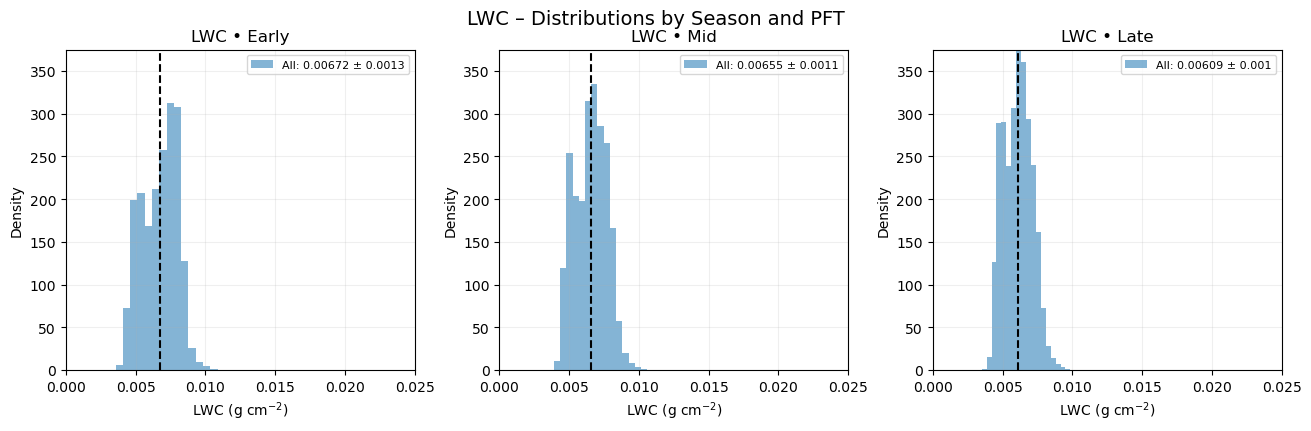

Saved: ./figures/lwc_distributions_by_season.png


In [8]:
def plot_lwc_only(LWC_vals, pft=None, outdir="./figures"):
    """Plot only LWC distributions by season and PFT"""
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
    
    # Choose classes
    if pft is None:
        pft_classes = {0: "All"}
        pft_mask = None
    else:
        pft_classes = PFT_CLASSES
        pft_mask = pft
    
    for col, (season_name, idxs) in enumerate(groups.items()):
        ax = axes[col]
        # Select time slice(s)
        d = LWC_vals.isel(time=idxs)
        # Collapse time by stacking
        d = d.stack(z=("time","lat","lon")).transpose("z")
        
        # For PFT classes
        for k, name in pft_classes.items():
            if pft_mask is None:
                vals = d.values
            else:
                # Broadcast mask and select matching class id
                m = (pft_mask == k)
                mv = np.broadcast_to(m.values, d.isel(time=0).values.shape) if "time" in d.unstack("z").dims else m.values
                # Apply across each time and stack
                vals = d.unstack("z").where(m, np.nan).stack(z=("time","lat","lon")).values
            vals = vals[np.isfinite(vals)]
            if vals.size == 0:
                continue
            # Plot histogram
            ax.hist(vals, bins=NBINS, density=True, alpha=ALPHA, label=f"{name}: {stats_string(vals)}",
                    color=COLORS.get(k, None))
            # Mean line
            mu = np.nanmean(vals)
            ax.axvline(mu, linestyle="--", linewidth=1.5, color=COLORS.get(k, "k"))
        
        ax.set_ylabel("Density")
        ax.set_xlabel(f"LWC ({LWC_unit})")
        ax.set_title(f"LWC • {season_name}")
        ax.set_xlim(0, 0.025)
        ax.set_ylim(0, 375)
        ax.legend(fontsize=8, frameon=True)
        ax.grid(True, alpha=0.2)
    
    fout = os.path.join(outdir, "lwc_distributions_by_season.png")
    fig.suptitle("LWC – Distributions by Season and PFT", fontsize=14, y=1.04)
    fig.savefig(fout, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", fout)

# Plot only LWC
plot_lwc_only(LWC_vals, pft=pft)

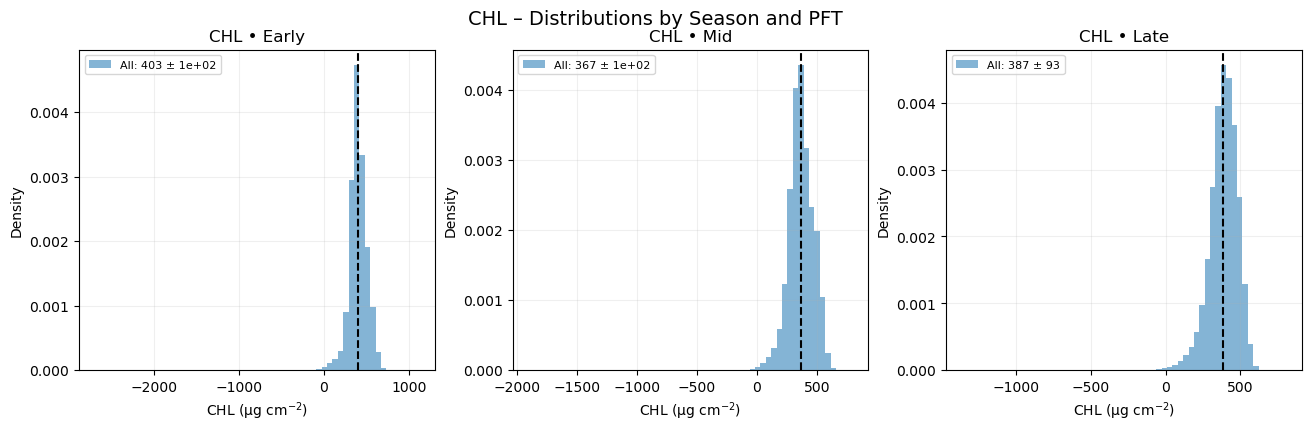

Saved: ./figures/chl_distributions_by_season.png


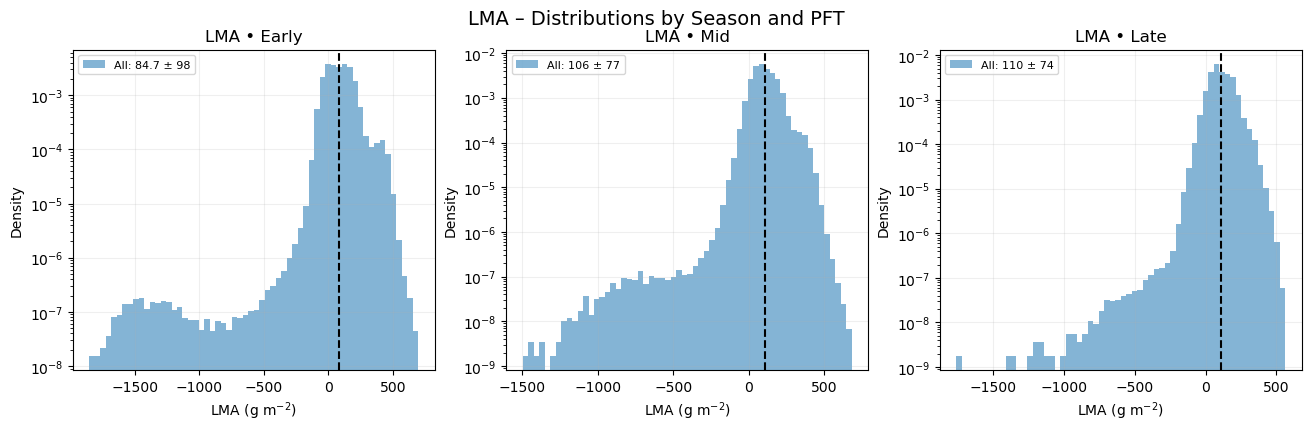

Saved: ./figures/lma_distributions_by_season.png


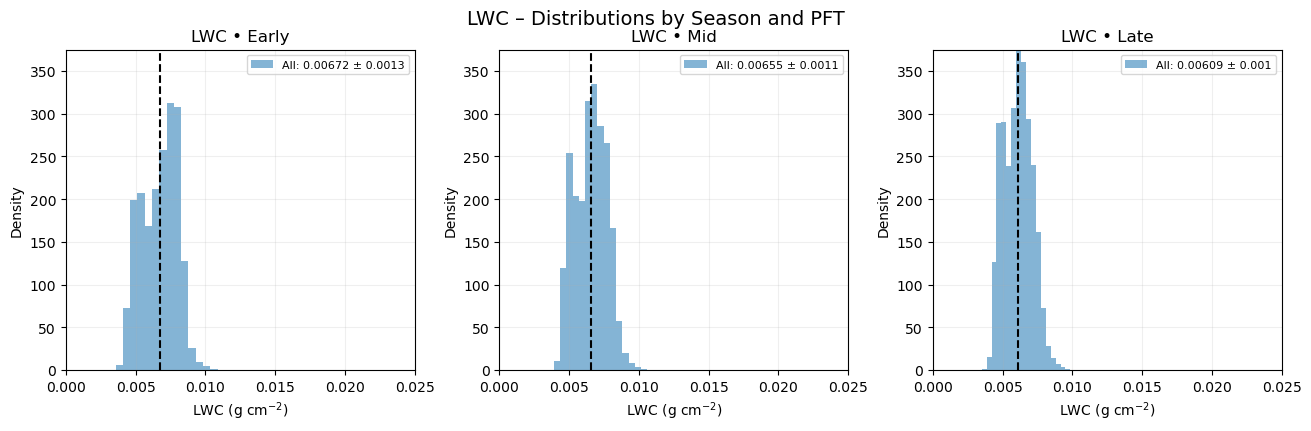

Saved: ./figures/lwc_distributions_by_season.png


In [9]:
def plot_chl_only(CHL_vals, pft=None, outdir="./figures"):
    """Plot only CHL distributions by season and PFT"""
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
    
    # Choose classes
    if pft is None:
        pft_classes = {0: "All"}
        pft_mask = None
    else:
        pft_classes = PFT_CLASSES
        pft_mask = pft
    
    for col, (season_name, idxs) in enumerate(groups.items()):
        ax = axes[col]
        # Select time slice(s)
        d = CHL_vals.isel(time=idxs)
        # Collapse time by stacking
        d = d.stack(z=("time","lat","lon")).transpose("z")
        
        # For PFT classes
        for k, name in pft_classes.items():
            if pft_mask is None:
                vals = d.values
            else:
                # Broadcast mask and select matching class id
                m = (pft_mask == k)
                mv = np.broadcast_to(m.values, d.isel(time=0).values.shape) if "time" in d.unstack("z").dims else m.values
                # Apply across each time and stack
                vals = d.unstack("z").where(m, np.nan).stack(z=("time","lat","lon")).values
            vals = vals[np.isfinite(vals)]
            if vals.size == 0:
                continue
            # Plot histogram
            ax.hist(vals, bins=NBINS, density=True, alpha=ALPHA, label=f"{name}: {stats_string(vals)}",
                    color=COLORS.get(k, None))
            # Mean line
            mu = np.nanmean(vals)
            ax.axvline(mu, linestyle="--", linewidth=1.5, color=COLORS.get(k, "k"))
        
        ax.set_ylabel("Density")
        ax.set_xlabel(f"CHL ({CHL_unit})")
        ax.set_title(f"CHL • {season_name}")
        ax.legend(fontsize=8, frameon=True)
        ax.grid(True, alpha=0.2)
    
    fout = os.path.join(outdir, "chl_distributions_by_season.png")
    fig.suptitle("CHL – Distributions by Season and PFT", fontsize=14, y=1.04)
    fig.savefig(fout, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", fout)

def plot_lma_only(LMA_vals, pft=None, outdir="./figures"):
    """Plot only LMA distributions by season and PFT"""
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
    
    # Choose classes
    if pft is None:
        pft_classes = {0: "All"}
        pft_mask = None
    else:
        pft_classes = PFT_CLASSES
        pft_mask = pft
    
    for col, (season_name, idxs) in enumerate(groups.items()):
        ax = axes[col]
        # Select time slice(s)
        d = LMA_vals.isel(time=idxs)
        # Collapse time by stacking
        d = d.stack(z=("time","lat","lon")).transpose("z")
        
        # For PFT classes
        for k, name in pft_classes.items():
            if pft_mask is None:
                vals = d.values
            else:
                # Broadcast mask and select matching class id
                m = (pft_mask == k)
                mv = np.broadcast_to(m.values, d.isel(time=0).values.shape) if "time" in d.unstack("z").dims else m.values
                # Apply across each time and stack
                vals = d.unstack("z").where(m, np.nan).stack(z=("time","lat","lon")).values
            vals = vals[np.isfinite(vals)]
            if vals.size == 0:
                continue
            # Plot histogram
            ax.hist(vals, bins=NBINS, density=True, alpha=ALPHA, label=f"{name}: {stats_string(vals)}",
                    color=COLORS.get(k, None))
            # Mean line
            mu = np.nanmean(vals)
            ax.axvline(mu, linestyle="--", linewidth=1.5, color=COLORS.get(k, "k"))
        
        ax.set_ylabel("Density")
        ax.set_xlabel(f"LMA ({LMA_unit})")
        ax.set_title(f"LMA • {season_name}")
        ax.set_yscale("log")
        ax.legend(fontsize=8, frameon=True)
        ax.grid(True, alpha=0.2)
    
    fout = os.path.join(outdir, "lma_distributions_by_season.png")
    fig.suptitle("LMA – Distributions by Season and PFT", fontsize=14, y=1.04)
    fig.savefig(fout, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", fout)

# Plot individual traits
plot_chl_only(CHL_vals, pft=pft)
plot_lma_only(LMA_vals, pft=pft)
plot_lwc_only(LWC_vals, pft=pft)


In [10]:

def save_single_panels(CHL_vals, LMA_vals, LWC_vals, pft=None, outdir=OUTDIR):
    os.makedirs(outdir, exist_ok=True)
    for var_label, data, unit in [("CHL", CHL_vals, CHL_unit),
                                  ("LMA", LMA_vals, LMA_unit),
                                  ("LWC", LWC_vals, LWC_unit)]:
        fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), constrained_layout=True)
        for ax, (season_name, idxs) in zip(axes, groups.items()):
            d = data.isel(time=idxs).stack(z=("time","lat","lon")).transpose("z").values
            d = d[np.isfinite(d)]
            ax.hist(d, bins=NBINS, density=True, alpha=0.7, color="tab:blue")
            ax.axvline(np.nanmean(d), linestyle="--", color="tab:blue")
            ax.set_title(season_name)
            ax.set_xlabel(f"{var_label} ({unit})")
            ax.set_ylabel("Density")
            if var_label == "LMA":
                ax.set_yscale("log")
            ax.grid(True, alpha=0.2)
        fout = os.path.join(outdir, f"{var_label}_by_season.png")
        fig.suptitle(f"{var_label} by Season", fontsize=13)
        fig.savefig(fout, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved:", fout)

# Uncomment to also export single-variable panels
# save_single_panels(CHL_vals, LMA_vals, LWC_vals, pft=pft)



### Notes on units
- **LWC** in the PLSR stack is typically *leaf-level EWT* in **g m⁻²** (one-sided leaf area). The notebook converts to **g cm⁻²** by dividing by 10,000 to match manuscript plots.
- **LMA** is expected in **g m⁻²**.
- **CHL** units vary by product; if yours are *g m⁻²*, set `CHL_CONV = ("µg cm$^{-2}$", lambda x: x*1e5)` or appropriate mapping.

### Season definition
- Early/Mid/Late are defined by tertiles of the available acquisition dates in `time`. If you prefer calendar cutoffs, replace the helper `season_labels_from_time` accordingly.

### PFT stratification
- If you have a PFT mask on the same grid, set `PFT_MASK_PATH` and `PFT_CLASSES`. With `None`, plots will show a single class "All".


## In Situ Comparison

Load in situ leaf trait measurements and compare with PLSR-derived values.

In [11]:
# --- IN SITU DATA CONFIG ---
INSITU_PATH = "/home/renatob/data/FluoData1/aviris_dangermond/in_situ/SHIFT_Leaf_Traits_Chl_SB_CA/data/leaf_traits.nc"

# Load in situ data
insitu_ds = xr.open_dataset(INSITU_PATH)
print("In situ dataset:")
print(insitu_ds)

# Extract in situ traits
insitu_CHL = insitu_ds['CHL']
insitu_LMA = insitu_ds['LMA'] 
insitu_LWC = insitu_ds['LWC']

# Apply same unit conversions as PLSR data
insitu_CHL_vals, _ = apply_conv(insitu_CHL, CHL_CONV)
insitu_LMA_vals, _ = apply_conv(insitu_LMA, LMA_CONV)
insitu_LWC_vals, _ = apply_conv(insitu_LWC, LWC_CONV)

print(f"\nIn situ time range: {insitu_ds.time.min().values} to {insitu_ds.time.max().values}")
print(f"PLSR time range: {ds.time.min().values} to {ds.time.max().values}")

In situ dataset:
<xarray.Dataset> Size: 2GB
Dimensions:    (time: 646, latitude: 536, longitude: 536)
Coordinates:
  * time       (time) float64 5kB 1.647e+09 1.653e+09 ... 9.969e+36 9.969e+36
  * latitude   (latitude) float32 2kB 34.44 34.44 34.44 ... 34.58 34.58 34.58
  * longitude  (longitude) float32 2kB -120.5 -120.5 -120.5 ... -120.3 -120.3
Data variables:
    CHL        (time, latitude, longitude) float32 742MB ...
    LMA        (time, latitude, longitude) float32 742MB ...
    LWC        (time, latitude, longitude) float32 742MB ...

In situ time range: 1645574400.0 to 9.969209968386869e+36
PLSR time range: 2022-02-24T00:00:00.000000000 to 2022-05-29T00:00:00.000000000


In [12]:
from scipy.stats import pearsonr, linregress
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def compare_plsr_vs_insitu(plsr_vals, insitu_vals, trait_name, unit, outdir="./figures"):
    """
    Compare PLSR-derived values with in situ measurements
    Creates scatter plot and calculates statistics
    """
    # Flatten and get valid (non-NaN) pairs
    plsr_flat = plsr_vals.values.flatten()
    insitu_flat = insitu_vals.values.flatten()
    
    # Find common valid indices
    valid = ~np.isnan(plsr_flat) & ~np.isnan(insitu_flat)
    plsr_valid = plsr_flat[valid]
    insitu_valid = insitu_flat[valid]
    
    if len(plsr_valid) == 0:
        print(f"No valid comparison points for {trait_name}")
        return
    
    # Calculate statistics
    r, p_value = pearsonr(plsr_valid, insitu_valid)
    r2 = r2_score(insitu_valid, plsr_valid)
    rmse = np.sqrt(mean_squared_error(insitu_valid, plsr_valid))
    mae = mean_absolute_error(insitu_valid, plsr_valid)
    bias = np.mean(plsr_valid - insitu_valid)
    slope, intercept, _, _, _ = linregress(insitu_valid, plsr_valid)
    
    # Create scatter plot
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Hexbin plot for density
    hexbin = ax.hexbin(insitu_valid, plsr_valid, gridsize=30, cmap='Blues', mincnt=1)
    
    # 1:1 line
    min_val = min(insitu_valid.min(), plsr_valid.min())
    max_val = max(insitu_valid.max(), plsr_valid.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='1:1 line')
    
    # Regression line
    x_line = np.array([min_val, max_val])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, 'r-', lw=2, label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
    
    # Labels and title
    ax.set_xlabel(f'In Situ {trait_name} ({unit})', fontsize=14)
    ax.set_ylabel(f'PLSR {trait_name} ({unit})', fontsize=14)
    ax.set_title(f'{trait_name}: PLSR vs In Situ', fontsize=16, fontweight='bold')
    
    # Statistics text box
    stats_text = f'N = {len(plsr_valid)}\n'
    stats_text += f'R = {r:.3f} (p<0.001)\n' if p_value < 0.001 else f'R = {r:.3f} (p={p_value:.3f})\n'
    stats_text += f'R² = {r2:.3f}\n'
    stats_text += f'RMSE = {rmse:.3f}\n'
    stats_text += f'MAE = {mae:.3f}\n'
    stats_text += f'Bias = {bias:.3f}'
    
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Colorbar
    cbar = plt.colorbar(hexbin, ax=ax)
    cbar.set_label('Count', fontsize=12)
    
    ax.legend(loc='lower right', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')
    
    # Save figure
    fout = os.path.join(outdir, f"{trait_name.lower()}_plsr_vs_insitu.png")
    fig.savefig(fout, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fout}")
    
    # Print statistics
    print(f"\n{trait_name} Comparison Statistics:")
    print(f"  N = {len(plsr_valid)}")
    print(f"  R = {r:.4f} (p = {p_value:.4e})")
    print(f"  R² = {r2:.4f}")
    print(f"  RMSE = {rmse:.4f} {unit}")
    print(f"  MAE = {mae:.4f} {unit}")
    print(f"  Bias = {bias:.4f} {unit}")
    print(f"  Slope = {slope:.4f}")
    print(f"  Intercept = {intercept:.4f}")

# Compare each trait
print("Comparing CHL...")
compare_plsr_vs_insitu(CHL_vals, insitu_CHL_vals, "CHL", CHL_unit, OUTDIR)

print("\nComparing LMA...")
compare_plsr_vs_insitu(LMA_vals, insitu_LMA_vals, "LMA", LMA_unit, OUTDIR)

print("\nComparing LWC...")
compare_plsr_vs_insitu(LWC_vals, insitu_LWC_vals, "LWC", LWC_unit, OUTDIR)

Comparing CHL...


ValueError: operands could not be broadcast together with shapes (88663476,) (185593216,) 